In [2]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('./input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [3]:
%pip install torchinfo
import PIL
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import re, os, sys, json, cv2, random
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchinfo import summary
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, f1_score, confusion_matrix, classification_report
import seaborn as sns

Note: you may need to restart the kernel to use updated packages.


In [1]:
!kaggle datasets download -d kmader/food41

Dataset URL: https://www.kaggle.com/datasets/kmader/food41
License(s): copyright-authors
food41.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
import zipfile

with zipfile.ZipFile('./food41.zip', 'r') as zip_ref:
    zip_ref.extractall('./dataset')

waffles                : 100%|███████████████████████████████████████████| 200/200 [00:00<00:00, 957.67file/s]


101 kind of images were found in the dataset
101000 images were found in the dataset.
16158 for training, 4040 for validation
average image height=  477  average image width=  488  aspect ratio h/w=  0.9774590163934426


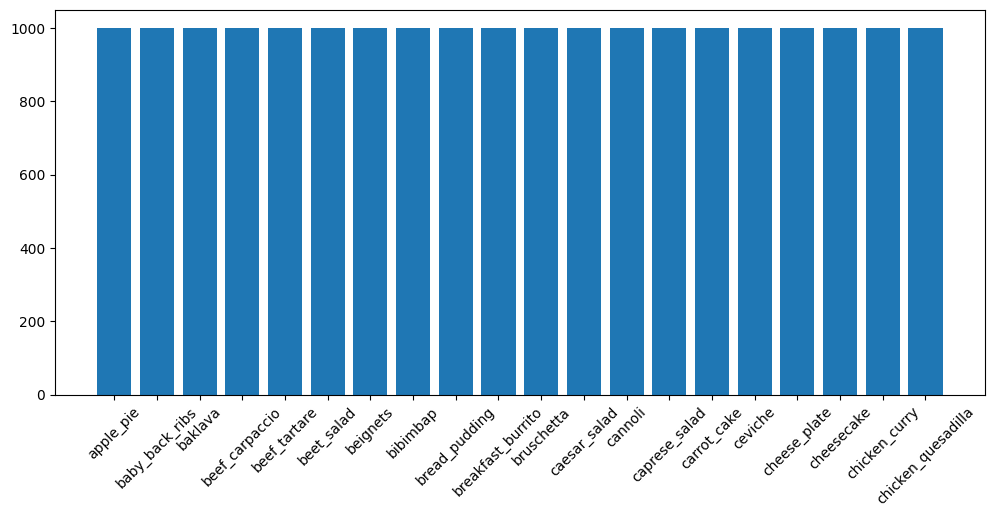

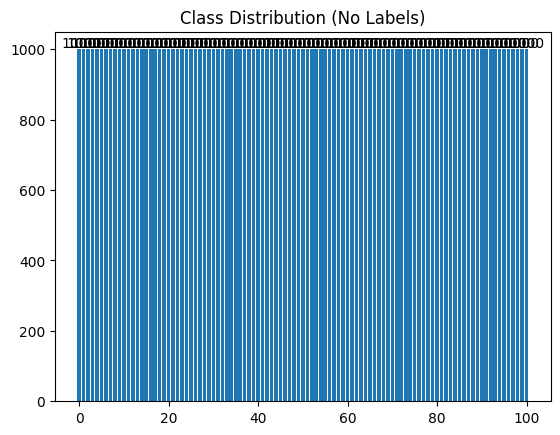

In [7]:
root = './dataset/images'
def read_split_data(root, plot_image=False):
    filepaths = []
    labels = []
    bad_images = []
 
    random.seed(0)
    assert os.path.exists(root), 'wdnmd'
 
    classes = [cla for cla in os.listdir(root) if os.path.isdir(os.path.join(root, cla))]
    classes.sort()
    class_indices = {k: v for v, k in enumerate(classes)}
 
    json_str = json.dumps({v: k for k, v in class_indices.items()}, indent=4)
 
    with open('classes_indices.json', 'w') as json_file:
        json_file.write(json_str)
 
    every_class_num = []
    supported = ['.jpg', '.png', '.jpeg', '.PNG', '.JPG', '.JPEG']
 
    for klass in classes:
        classpath = os.path.join(root, klass)
        images = [
            os.path.join(root, klass, i)
            for i in os.listdir(classpath)
            if os.path.splitext(i)[-1] in supported
        ]
 
        every_class_num.append(len(images))
        flist = sorted(os.listdir(classpath))
        desc = f'{klass:23s}'
 
        for f in tqdm(flist[:200], ncols=110, desc=desc, unit='file', colour='blue'):
            fpath = os.path.join(classpath, f)
            f1 = f.lower()
            index = f1.rfind('.')
            ext = f1[index:]
 
            if ext in supported:
                image = Image.open(fpath)
 
                if image.mode == 'RGB':
                    try:
                        img = cv2.imread(fpath)
                        filepaths.append(fpath)
                        labels.append(klass)
                    except:
                        bad_images.append(fpath)
                        print('defective image file: ', fpath)
                else:
                    bad_images.append(fpath)
 
    Fseries = pd.Series(filepaths, name='filepaths')
    Lseries = pd.Series(labels, name='labels')
    df = pd.concat([Fseries, Lseries], axis=1)
 
    print(f'{len(df.labels.unique())} kind of images were found in the dataset')
 
    train_df, test_df = train_test_split(
        df,
        train_size=.8,
        shuffle=True,
        random_state=123,
        stratify=df['labels']
    )
 
    train_image_path = train_df['filepaths'].tolist()
    val_image_path = test_df['filepaths'].tolist()
 
    train_image_label = [class_indices[i] for i in train_df['labels'].tolist()]
    val_image_label = [class_indices[i] for i in test_df['labels'].tolist()]
 
    sample_df = train_df.sample(n=50, replace=False)
 
    ht, wt, count = 0, 0, 0
 
    for i in range(len(sample_df)):
        fpath = sample_df['filepaths'].iloc[i]
        try:
            img = cv2.imread(fpath)
            h = img.shape[0]
            w = img.shape[1]
            ht += h
            wt += w
            count += 1
        except:
            pass
 
    have = int(ht / count)
    wave = int(wt / count)
    aspect_ratio = have / wave
 
    print('{} images were found in the dataset.\n{} for training, {} for validation'.format(
        sum(every_class_num),
        len(train_image_path),
        len(val_image_path)
    ))
 
    print(
        'average image height= ', have,
        ' average image width= ', wave,
        ' aspect ratio h/w= ', aspect_ratio
    )
 
    if plot_image:
        plt.figure(figsize=(12, 5))
        plt.bar(range(20), every_class_num[:20], align='center')
        plt.xticks(range(20), classes[:20], rotation=45)
        plt.show()
 
        for i, v in enumerate(every_class_num):
            plt.text(x=i, y=v + 5, s=str(v), ha='center')
 
        plt.bar(range(len(classes)), every_class_num)
        plt.title("Class Distribution (No Labels)")
        plt.show()
 
    return train_image_path, train_image_label, val_image_path, val_image_label, class_indices
 
 
train_image_path, train_image_label, val_image_path, val_image_label, class_indices = read_split_data(
    root, plot_image=True
)